In [90]:
# -*- coding: utf-8 -*-
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import math
import importlib
import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
from torchvision import models
from torchvision import transforms

# My libs
from core.utils import Stack, ToTorchFormatTensor
from model.depth_completion import DepthCompletion, ContentReconstruction, ContentEnhancement

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# set up stage-1 (depth compeltion) pretrained model
stage1_model = DepthCompletion().to(device)
data = torch.load('checkpoints/stage1.pth', map_location=device)
stage1_model.load_state_dict(data["netG"])
print("loading from: {}".format('checkpoints/stage1.pth'))
stage1_model.eval();

loading from: checkpoints/stage1.pth


In [150]:
def _to_tensor(depths):
    b, t, c, h, w = depths.shape
    depths = depths.view(b, t, c, -1)
    depth_min = torch.min(depths, dim=-1)[0].unsqueeze(-1)
    depth_max = torch.max(depths, dim=-1)[0].unsqueeze(-1)

    out = (depths - depth_min) / (depth_max - depth_min)
    out = out.view(b, t, c, h, w)
    return out

def get_random_focus_depths():

    # Define focal range
    window = random.uniform(0.3, 0.5)
    focal_point = random.uniform(0, 1)

    if focal_point >= 1 - window:
        d1 = 1 - window
        d2 = 1
    elif focal_point <= window:
        d1 = 0
        d2 = window
    else:
        d1 = focal_point - window
        d2 = focal_point + window

    return d1, d2, focal_point


def generate_random_depth_mask(depth, d1, d2, focal_point):

    # Scale depth to [0, 1]
    depth = depth / np.max(depth)

    # Initialize mask
    mask = np.zeros((depth.shape[0], depth.shape[1]))

    # Add focus pull
    v = random.uniform(0.01, 0.03)
    if focal_point >= 0.5:
        d1 += v
        d2 -= v
    else:
        d1 -= v
        d2 += v

    # Infill depths outside of focal range
    mask[depth < d1] = 1
    mask[depth > d2] = 1

    return d1, d2, Image.fromarray(mask).convert("L")

   




    


In [151]:
dpath = "T:/ProPainter Datasets/davis/depths/judo/00000_depth.png"
ipath = "T:/ProPainter Datasets/davis/JPEGImages/judo/00000.png"

# w = 640
# h = 480

d = Image.open(dpath)
# d = d.resize((w, h), Image.NEAREST)
d = np.array(d.convert("L"))
# d = np.array(d > 0).astype(np.uint8)
d = cv2.dilate(
    d, cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3)), iterations=4
)



dep_1 = np.expand_dims(d, axis=0)
dep_2 = np.expand_dims(dep_1, axis=0)
depth = np.expand_dims(dep_2, axis=0)
depth = torch.from_numpy(depth)
print(d.shape)
print(depth.shape)

(240, 432)
torch.Size([1, 1, 1, 240, 432])


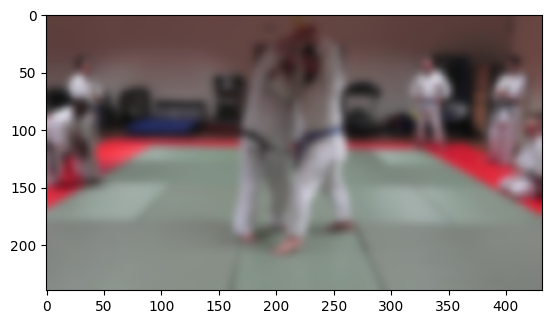

In [152]:

d1, d2, focal_point = get_random_focus_depths()
d1, d2, mask = generate_random_depth_mask(d, d1, d2, focal_point)


img = np.array(Image.open(ipath))
mask = torch.from_numpy(np.array(mask)).to(device)
depth = depth.to(device)


blurry_img = get_blurred_frame(img)
plt.imshow(blurry_img)

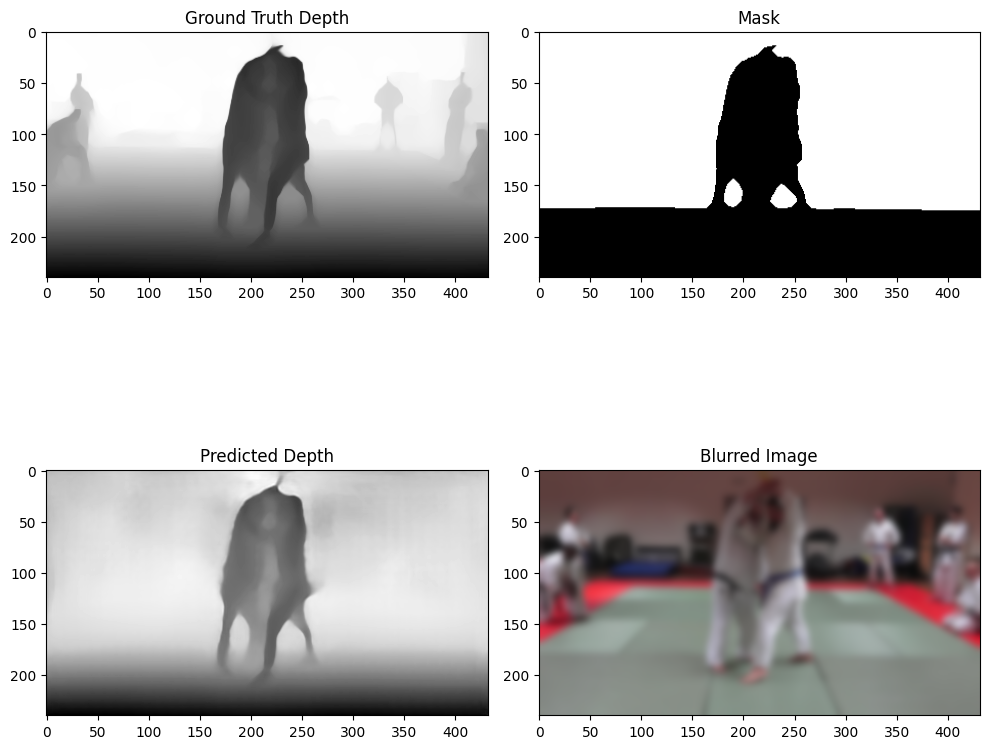

In [153]:





with torch.no_grad():
    # depth = torch.nn.functional.interpolate(
    #     d, size=[h, w], mode="bicubic", align_corners=False
    # ).view(1, 1, 1, h, w)

    depth = _to_tensor(depth)
    pred_depths = stage1_model(
        depth * (1.0 - mask).float(), mask
)


fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot ground truth depth
axs[0, 0].imshow(d, cmap='gray')
axs[0, 0].set_title('Ground Truth Depth')

# Plot mask
axs[0, 1].imshow(mask.cpu().numpy(), cmap='gray')
axs[0, 1].set_title('Mask')

# Plot predicted depth
axs[1, 0].imshow(pred_depths.cpu().numpy()[0, 0, :, :], cmap='gray')
axs[1, 0].set_title('Predicted Depth')

# Plot blurred image
axs[1, 1].imshow(blurry_img)
axs[1, 1].set_title('Blurred Image')

plt.tight_layout()

plt.show()
